Loaded preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Loaded data_split type: <class 'tuple'>
Loaded label_encoder type: <class 'sklearn.preprocessing._label.LabelEncoder'>
X_train shape: (5285, 19)
X_test shape: (1322, 19)
y_train shape: (5285,)
y_test shape: (1322,)
Processed X_train shape: (5285, 40)
Processed X_test shape: (1322, 40)

Random Forest Accuracy: 0.8903

Classification Report:

              precision    recall  f1-score   support

        Fail       0.88      0.99      0.93       997
        Pass       0.95      0.58      0.72       325

    accuracy                           0.89      1322
   macro avg       0.92      0.79      0.83      1322
weighted avg       0.90      0.89      0.88      1322



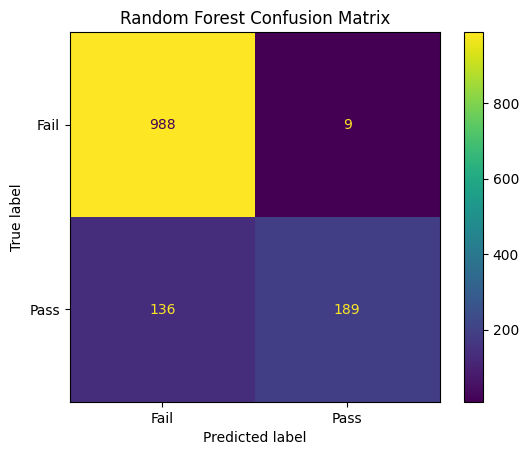

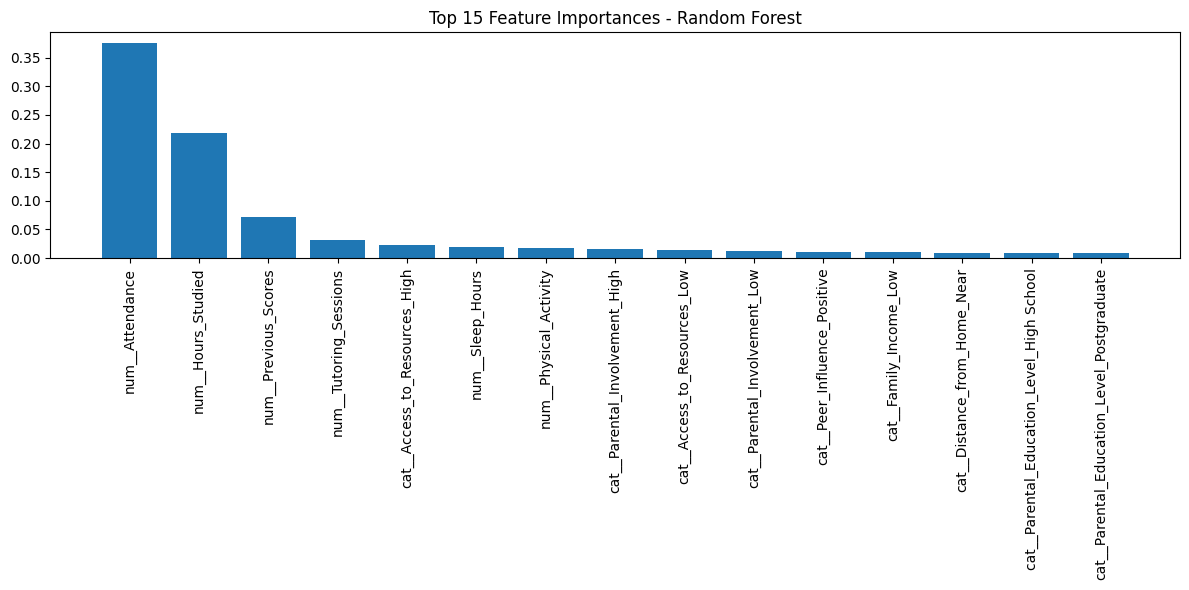


Top 15 Important Features:
num__Attendance: 0.3757
num__Hours_Studied: 0.2187
num__Previous_Scores: 0.0721
num__Tutoring_Sessions: 0.0323
cat__Access_to_Resources_High: 0.0231
num__Sleep_Hours: 0.0199
num__Physical_Activity: 0.0175
cat__Parental_Involvement_High: 0.0152
cat__Access_to_Resources_Low: 0.0134
cat__Parental_Involvement_Low: 0.0131
cat__Peer_Influence_Positive: 0.0107
cat__Family_Income_Low: 0.0106
cat__Distance_from_Home_Near: 0.0095
cat__Parental_Education_Level_High School: 0.0092
cat__Parental_Education_Level_Postgraduate: 0.0090


In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ======================================
# 1. Load shared artifacts
# ======================================
preprocessor = joblib.load("../preprocessor.pkl")
data_split = joblib.load("../data_split.pkl")
label_encoder = joblib.load("../label_encoder.pkl")

print("Loaded preprocessor type:", type(preprocessor))
print("Loaded data_split type:", type(data_split))
print("Loaded label_encoder type:", type(label_encoder))

# ======================================
# 2. Unpack train/test data safely
# ======================================
if isinstance(data_split, dict):
    X_train = data_split["X_train"]
    X_test = data_split["X_test"]
    y_train = data_split["y_train"]
    y_test = data_split["y_test"]

elif isinstance(data_split, tuple) or isinstance(data_split, list):
    if len(data_split) == 4:
        X_train, X_test, y_train, y_test = data_split
    else:
        raise ValueError(
            f"Expected data_split tuple/list of length 4, but got length {len(data_split)}"
        )
else:
    raise TypeError(
        f"Unsupported data_split type: {type(data_split)}. Expected dict, tuple, or list."
    )

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", np.shape(y_train))
print("y_test shape:", np.shape(y_test))

# ======================================
# 3. Apply preprocessing
# ======================================
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

# ======================================
# 4. Train Random Forest model
# ======================================
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

# ======================================
# 5. Predict
# ======================================
y_pred = rf_model.predict(X_test_processed)

# ======================================
# 6. Evaluation
# ======================================
accuracy = accuracy_score(y_test, y_pred)
print(f"\nRandom Forest Accuracy: {accuracy:.4f}")

# Handle label names safely
class_names = None
if hasattr(label_encoder, "classes_"):
    class_names = label_encoder.classes_

print("\nClassification Report:\n")
if class_names is not None:
    print(classification_report(y_test, y_pred, target_names=class_names))
else:
    print(classification_report(y_test, y_pred))

# ======================================
# 7. Confusion Matrix
# ======================================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names if class_names is not None else None
)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# ======================================
# 8. Feature Importance
# ======================================
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_train_processed.shape[1])]

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(12, 6))
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=90)
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

print("\nTop 15 Important Features:")
for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test_processed)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.9080417280880594
Tuned Accuracy: 0.8986384266263238
